In [1]:

# Imports and config

import os, glob, time, random, math, copy, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, mean_squared_error, mean_absolute_error
)
from sklearn.datasets import load_diabetes

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

BATCH_SIZE = 256
NUM_WORKERS = 2
EARLY_TEST_EVAL = False

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()


Device: cpu


## 1. Environment Setup — Fashion-MNIST

In [2]:

# 1. Load Fashion-MNIST


def find_file(names):
    roots = ["/kaggle/input", "/mnt/data", "."]
    for root in roots:
        for name in names:
            matches = glob.glob(os.path.join(root, "**", name), recursive=True)
            if matches:
                return matches[0]
    return None

train_csv = find_file([
    "fashion-mnist_train.csv",
    "fashion-mnist_train.csv.zip"
])
test_csv = find_file([
    "fashion-mnist_test.csv",
    "fashion-mnist_test.csv.zip"
])

def load_fashion_csv(train_path, test_path):
    import zipfile

    def read_any(path):
        if path.endswith(".zip"):
            with zipfile.ZipFile(path) as z:
                csvs = [x for x in z.namelist() if x.lower().endswith(".csv")]
                assert csvs, f"No CSV inside {path}"
                with z.open(csvs[0]) as f:
                    return pd.read_csv(f)
        return pd.read_csv(path)

    tr = read_any(train_path)
    te = read_any(test_path)
    return tr, te

if train_csv and test_csv:
    print("Using Kaggle CSV files:")
    print(train_csv)
    print(test_csv)
    train_df, test_df = load_fashion_csv(train_csv, test_csv)

    label_col = "label" if "label" in train_df.columns else train_df.columns[0]
    X_all = train_df.drop(columns=[label_col]).to_numpy(dtype=np.float32) / 255.0
    y_all = train_df[label_col].to_numpy(dtype=np.int64)

    test_label_col = "label" if "label" in test_df.columns else test_df.columns[0]
    X_test = test_df.drop(columns=[test_label_col]).to_numpy(dtype=np.float32) / 255.0
    y_test = test_df[test_label_col].to_numpy(dtype=np.int64)
else:
    from torchvision.datasets import FashionMNIST
    root = "/kaggle/working/fashion_mnist"
    tr_ds = FashionMNIST(root=root, train=True, download=True)
    te_ds = FashionMNIST(root=root, train=False, download=True)
    X_all = tr_ds.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
    y_all = tr_ds.targets.numpy().astype(np.int64)
    X_test = te_ds.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
    y_test = te_ds.targets.numpy().astype(np.int64)

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all
)

print(f"Training samples:   {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Provided test set:  {len(X_test):,} (held out)")

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

dist = pd.DataFrame({
    "class_id": np.arange(10),
    "class_name": class_names,
    "train": np.bincount(y_train, minlength=10),
    "validation": np.bincount(y_val, minlength=10),
    "test": np.bincount(y_test, minlength=10)
})
display(dist)

assert X_train.shape[1] == 784
assert X_train.min() >= 0 and X_train.max() <= 1


Using Kaggle CSV files:
.\archive\fashion-mnist_train.csv
.\archive\fashion-mnist_test.csv
Training samples:   48,000
Validation samples: 12,000
Provided test set:  10,000 (held out)


,class_id,class_name,train,validation,test
0,0,T-shirt/top,4800,1200,1000
1,1,Trouser,4800,1200,1000
2,2,Pullover,4800,1200,1000
3,3,Dress,4800,1200,1000
4,4,Coat,4800,1200,1000
5,5,Sandal,4800,1200,1000
6,6,Shirt,4800,1200,1000
7,7,Sneaker,4800,1200,1000
8,8,Bag,4800,1200,1000
9,9,Ankle boot,4800,1200,1000


Epoch 01/10 | loss=1.3193
Epoch 02/10 | loss=0.8471
Epoch 03/10 | loss=0.7547
Epoch 04/10 | loss=0.6654
Epoch 05/10 | loss=0.6316
Epoch 06/10 | loss=0.5794
Epoch 07/10 | loss=0.5561
Epoch 08/10 | loss=0.5504
Epoch 09/10 | loss=0.5214
Epoch 10/10 | loss=0.5033


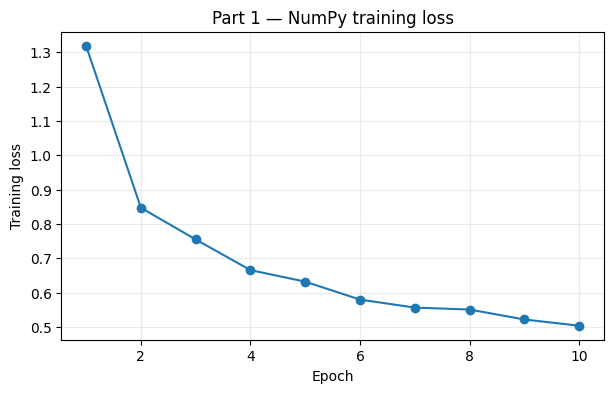

In [3]:

# Part 1: NumPy MLP


def one_hot(y, n_classes=10):
    out = np.zeros((len(y), n_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out

def relu_np(z):
    return np.maximum(0, z)

def softmax_np(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)

def init_numpy_params(seed=42):
    rng = np.random.default_rng(seed)

    W1 = (rng.standard_normal((784, 64)).astype(np.float32) * np.sqrt(2/784))
    b1 = np.zeros((1, 64), dtype=np.float32)
    W2 = (rng.standard_normal((64, 10)).astype(np.float32) * np.sqrt(2/64))
    b2 = np.zeros((1, 10), dtype=np.float32)
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def forward_np(X, p):
    z1 = X @ p["W1"] + p["b1"]
    a1 = relu_np(z1)
    z2 = a1 @ p["W2"] + p["b2"]
    probs = softmax_np(z2)
    cache = (X, z1, a1, probs)
    return probs, cache

def ce_np(probs, y):
    eps = 1e-12
    return -np.mean(np.log(probs[np.arange(len(y)), y] + eps))

def backward_np(y, p, cache):
    X, z1, a1, probs = cache
    n = len(X)

    dz2 = (probs - one_hot(y)) / n
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = dz2 @ p["W2"].T
    dz1 = da1 * (z1 > 0)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

def accuracy_np(X, y, p):
    probs, _ = forward_np(X, p)
    return np.mean(np.argmax(probs, axis=1) == y)

X_np = X_train[:5000]
y_np = y_train[:5000]

params_np = init_numpy_params(SEED)
lr_np = 0.1
epochs_np = 10
losses_np = []

rng = np.random.default_rng(SEED)

for epoch in range(epochs_np):
    idx = rng.permutation(len(X_np))
    epoch_loss = 0.0

    for start in range(0, len(X_np), 128):
        batch_idx = idx[start:start+128]
        xb, yb = X_np[batch_idx], y_np[batch_idx]

        probs, cache = forward_np(xb, params_np)
        loss = ce_np(probs, yb)
        grads = backward_np(yb, params_np, cache)

        for k in params_np:
            params_np[k] -= lr_np * grads[k]

        epoch_loss += loss * len(xb)

    epoch_loss /= len(X_np)
    losses_np.append(epoch_loss)
    print(f"Epoch {epoch+1:02d}/{epochs_np} | loss={epoch_loss:.4f}")

plt.figure(figsize=(7,4))
plt.plot(range(1, epochs_np+1), losses_np, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Part 1 — NumPy training loss")
plt.grid(True, alpha=0.25)
plt.show()


In [4]:


# Part 1: Gradient verification


class TorchMLP(nn.Module):
    def __init__(self, hidden=64, activation=nn.ReLU()):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden)
        self.fc2 = nn.Linear(hidden, 10)
        self.activation = activation

    def forward(self, x):
        return self.fc2(self.activation(self.fc1(x)))

torch_model = TorchMLP(64).to(DEVICE)

with torch.no_grad():
    torch_model.fc1.weight.copy_(torch.tensor(params_np["W1"].T, dtype=torch.float32, device=DEVICE))
    torch_model.fc1.bias.copy_(torch.tensor(params_np["b1"].ravel(), dtype=torch.float32, device=DEVICE))
    torch_model.fc2.weight.copy_(torch.tensor(params_np["W2"].T, dtype=torch.float32, device=DEVICE))
    torch_model.fc2.bias.copy_(torch.tensor(params_np["b2"].ravel(), dtype=torch.float32, device=DEVICE))

xb = X_np[:128]
yb = y_np[:128]

probs, cache = forward_np(xb, params_np)
np_grads = backward_np(yb, params_np, cache)

torch_model.zero_grad(set_to_none=True)
xt = torch.tensor(xb, dtype=torch.float32, device=DEVICE)
yt = torch.tensor(yb, dtype=torch.long, device=DEVICE)
logits = torch_model(xt)
loss_t = F.cross_entropy(logits, yt)
loss_t.backward()

torch_grads = {
    "W1": torch_model.fc1.weight.grad.detach().cpu().numpy().T,
    "b1": torch_model.fc1.bias.grad.detach().cpu().numpy().reshape(1,-1),
    "W2": torch_model.fc2.weight.grad.detach().cpu().numpy().T,
    "b2": torch_model.fc2.bias.grad.detach().cpu().numpy().reshape(1,-1)
}

grad_diffs = {k: np.max(np.abs(np_grads[k] - torch_grads[k])) for k in np_grads}
print("Maximum absolute gradient differences:")
for k, v in grad_diffs.items():
    print(f"{k}: {v:.8e}")

print("\nWeight-matrix differences:")
print(f"W1 max abs difference: {grad_diffs['W1']:.8e}")
print(f"W2 max abs difference: {grad_diffs['W2']:.8e}")
print("\nConclusion: differences close to floating-point precision indicate a correct implementation.")


Maximum absolute gradient differences:
W1: 1.52780628e-08
b1: 7.38798087e-09
W2: 5.36299806e-08
b2: 7.24207283e-09

Weight-matrix differences:
W1 max abs difference: 1.52780628e-08
W2 max abs difference: 5.36299806e-08

Conclusion: differences close to floating-point precision indicate a correct implementation.


## Part 2 — Baseline Model and Activation Study


Activation: sigmoid
Epoch 01/15 | train loss 1.4296 acc 0.5576 | val loss 0.8748 acc 0.7204
Epoch 02/15 | train loss 0.6906 acc 0.7709 | val loss 0.5798 acc 0.7897
Epoch 03/15 | train loss 0.5172 acc 0.8223 | val loss 0.4763 acc 0.8343
Epoch 04/15 | train loss 0.4469 acc 0.8451 | val loss 0.4387 acc 0.8414
Epoch 05/15 | train loss 0.4104 acc 0.8572 | val loss 0.4071 acc 0.8547
Epoch 06/15 | train loss 0.3845 acc 0.8653 | val loss 0.3888 acc 0.8598
Epoch 07/15 | train loss 0.3678 acc 0.8698 | val loss 0.3798 acc 0.8676
Epoch 08/15 | train loss 0.3540 acc 0.8755 | val loss 0.3714 acc 0.8672
Epoch 09/15 | train loss 0.3413 acc 0.8801 | val loss 0.3614 acc 0.8726
Epoch 10/15 | train loss 0.3304 acc 0.8827 | val loss 0.3520 acc 0.8745
Epoch 11/15 | train loss 0.3226 acc 0.8865 | val loss 0.3461 acc 0.8751
Epoch 12/15 | train loss 0.3154 acc 0.8890 | val loss 0.3486 acc 0.8714
Epoch 13/15 | train loss 0.3085 acc 0.8905 | val loss 0.3394 acc 0.8757
Epoch 14/15 | train loss 0.2996 acc 0.8938 

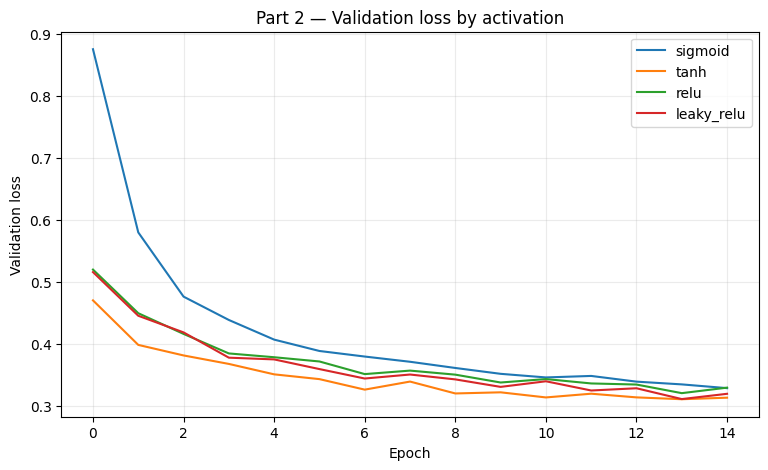

sigmoid: mean |gradient| epoch 1 = 6.40641674e-05, final = 2.97417684e-04
relu: mean |gradient| epoch 1 = 7.01177135e-04, final = 8.53721008e-04
Percentage of ReLU hidden units producing zero for every validation sample: 9.90%


In [5]:

# Shared training helpers


def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

class MLPClassifier(nn.Module):
    def __init__(self, widths=(128,64), activation="relu", dropout=0.0, batchnorm=False):
        super().__init__()
        act_map = {
            "relu": nn.ReLU(),
            "sigmoid": nn.Sigmoid(),
            "tanh": nn.Tanh(),
            "leaky_relu": nn.LeakyReLU(0.01)
        }
        layers = []
        in_dim = 784

        for w in widths:
            layers.append(nn.Linear(in_dim, w))
            if batchnorm:
                layers.append(nn.BatchNorm1d(w))
            layers.append(act_map[activation])
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = w

        layers.append(nn.Linear(in_dim, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def evaluate_model(model, X, y, batch_size=512):
    model.eval()
    loader = make_loader(X, y, batch_size, shuffle=False)
    correct, total, loss_sum = 0, 0, 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss_sum += loss.item() * len(xb)
            correct += (logits.argmax(1) == yb).sum().item()
            total += len(xb)
    return loss_sum/total, correct/total

def train_model(model, Xtr, ytr, Xv, yv, epochs=15, lr=1e-3,
                optimizer_name="adam", weight_decay=0.0, l1=0.0,
                patience=None, augmentation=False, verbose=True):

    model = model.to(DEVICE)

    if optimizer_name == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "momentum":
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        opt = torch.optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == "adam":
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(optimizer_name)

    if optimizer_name != "adam" and weight_decay > 0:
        for group in opt.param_groups:
            group["weight_decay"] = weight_decay

    train_loader = make_loader(Xtr, ytr, BATCH_SIZE, shuffle=True)
    criterion = nn.CrossEntropyLoss()

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [],
            "first_layer_grad_mean": []}

    best_state = None
    best_val = float("inf")
    wait = 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        grad_values = []

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)

            if l1 > 0:
                l1_term = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1 * l1_term

            loss.backward()

            for p in model.parameters():
                if p.grad is not None and p.ndim == 2:
                    grad_values.append(p.grad.detach().abs().mean().item())
                    break

            opt.step()
            running_loss += loss.item() * len(xb)
            correct += (logits.argmax(1) == yb).sum().item()
            total += len(xb)

        tr_loss = running_loss / total
        tr_acc = correct / total
        va_loss, va_acc = evaluate_model(model, Xv, yv)

        hist["train_loss"].append(tr_loss)
        hist["train_acc"].append(tr_acc)
        hist["val_loss"].append(va_loss)
        hist["val_acc"].append(va_acc)
        hist["first_layer_grad_mean"].append(np.mean(grad_values))

        if verbose:
            print(f"Epoch {epoch+1:02d}/{epochs} | "
                  f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
                  f"val loss {va_loss:.4f} acc {va_acc:.4f}")

        if patience is not None:
            if va_loss < best_val - 1e-4:
                best_val = va_loss
                best_state = copy.deepcopy(model.state_dict())
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    if verbose:
                        print("Early stopping triggered.")
                    break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, hist

activations = ["sigmoid", "tanh", "relu", "leaky_relu"]
activation_results = {}

for act in activations:
    print("\n" + "="*60)
    print("Activation:", act)
    seed_everything(SEED)
    m = MLPClassifier(widths=(128,64), activation=act)
    m, h = train_model(m, X_train, y_train, X_val, y_val,
                       epochs=15, lr=1e-3, optimizer_name="adam")
    activation_results[act] = (m, h)

plt.figure(figsize=(9,5))
for act in activations:
    plt.plot(activation_results[act][1]["val_loss"], label=act)
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Part 2 — Validation loss by activation")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

for act in ["sigmoid", "relu"]:
    h = activation_results[act][1]
    print(f"{act}: mean |gradient| epoch 1 = {h['first_layer_grad_mean'][0]:.8e}, "
          f"final = {h['first_layer_grad_mean'][-1]:.8e}")

relu_model = activation_results["relu"][0].eval()
xb = torch.tensor(X_val[:512], dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    x = xb
    dead_mask = None
    for layer in relu_model.net:
        x = layer(x)
        if isinstance(layer, nn.ReLU):
            z = x
            current_dead = (z == 0).all(dim=0)
            if dead_mask is None:
                dead_mask = current_dead
            else:
                dead_mask = torch.cat([dead_mask, current_dead])
dead_pct = 100 * dead_mask.float().mean().item()
print(f"Percentage of ReLU hidden units producing zero for every validation sample: {dead_pct:.2f}%")


### Part 2 interpretation

Write two sentences for vanishing gradients and two for dead ReLU units after running the cell. Use the actual gradient values and dead-unit percentage printed above.

Part 3 classification result (validation, because test remains untouched):
Cross-entropy validation accuracy: 0.8829
MSE validation accuracy:           0.8850


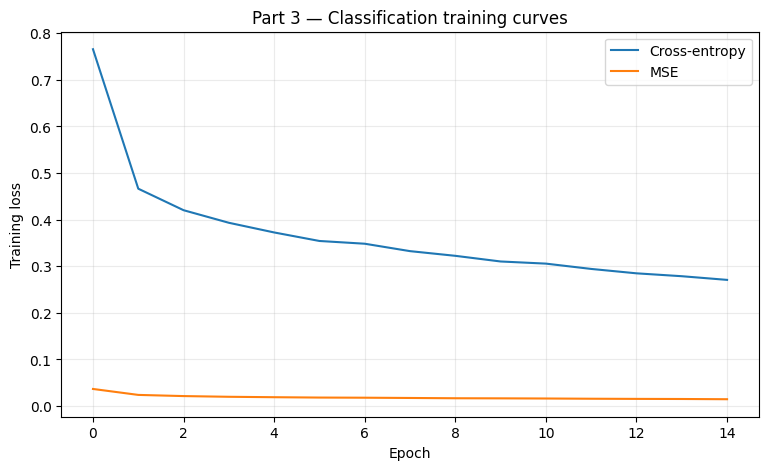


Tabular regression — sklearn Diabetes dataset
MSE :  3390.3672
RMSE:  58.2269
MAE :  49.3045


In [7]:

# Part 3: Cross-entropy vs MSE


class SoftmaxMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.net(x)

def train_ce_or_mse(loss_name, epochs=15, lr=1e-3):
    seed_everything(SEED)
    model = SoftmaxMLP().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loader = make_loader(X_train, y_train)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for ep in range(epochs):
        model.train()
        total_loss = 0.0

        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)

            if loss_name == "ce":
                loss = F.cross_entropy(logits, yb)
            else:
                probs = F.softmax(logits, dim=1)
                targets = F.one_hot(yb, num_classes=10).float()
                loss = F.mse_loss(probs, targets)

            loss.backward()
            opt.step()
            total_loss += loss.item() * len(xb)

        va_loss, va_acc = evaluate_model(model, X_val, y_val)
        history["train_loss"].append(total_loss / len(X_train))
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

    return model, history

ce_model, ce_hist = train_ce_or_mse("ce")
mse_model, mse_hist = train_ce_or_mse("mse")

print("Part 3 classification result (validation, because test remains untouched):")
print(f"Cross-entropy validation accuracy: {ce_hist['val_acc'][-1]:.4f}")
print(f"MSE validation accuracy:           {mse_hist['val_acc'][-1]:.4f}")

plt.figure(figsize=(9,5))
plt.plot(ce_hist["train_loss"], label="Cross-entropy")
plt.plot(mse_hist["train_loss"], label="MSE")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Part 3 — Classification training curves")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

diab = load_diabetes()
Xr = diab.data.astype(np.float32)
yr = diab.target.astype(np.float32).reshape(-1,1)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=SEED
)

reg_model = nn.Sequential(
    nn.Linear(Xr.shape[1], 32), nn.ReLU(),
    nn.Linear(32, 16), nn.ReLU(),
    nn.Linear(16, 1)
).to(DEVICE)

reg_opt = torch.optim.Adam(reg_model.parameters(), lr=1e-3)
reg_ds = TensorDataset(torch.tensor(Xr_train), torch.tensor(yr_train))
reg_loader = DataLoader(reg_ds, batch_size=32, shuffle=True)

for ep in range(100):
    reg_model.train()
    for xb, yb in reg_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        reg_opt.zero_grad(set_to_none=True)
        pred = reg_model(xb)
        loss = F.mse_loss(pred, yb)
        loss.backward()
        reg_opt.step()

reg_model.eval()
with torch.no_grad():
    pred_r = reg_model(torch.tensor(Xr_test).to(DEVICE)).cpu().numpy().ravel()

mse_r = mean_squared_error(yr_test.ravel(), pred_r)
rmse_r = np.sqrt(mse_r)
mae_r = mean_absolute_error(yr_test.ravel(), pred_r)

print("\nTabular regression — sklearn Diabetes dataset")
print(f"MSE :  {mse_r:.4f}")
print(f"RMSE:  {rmse_r:.4f}")
print(f"MAE :  {mae_r:.4f}")


**Comment:** Cross-entropy is normally better matched to mutually exclusive classification because it directly optimizes the log-probability of the correct class and gives useful gradients when predictions are confidently wrong. MSE treats the one-hot targets as continuous values and usually provides less suitable gradients for softmax classification, so convergence can be slower.

## Part 4 — Optimiser Comparison

Running same learning-rate experiments...
Running sgd...
Running momentum...
Running rmsprop...
Running adam...

Running tuned learning-rate experiments...
Running sgd...
Running momentum...
Running rmsprop...
Running adam...

Same learning rate:


,optimizer,learning_rate,epochs_to_85,wall_clock_seconds,final_val_accuracy
0,sgd,0.001,NaN,113.610712,0.314583
1,momentum,0.001,NaN,115.778662,0.748000
2,rmsprop,0.001,6.0,102.003255,0.872917
3,adam,0.001,3.0,101.546461,0.870417



Tuned learning rates:


,optimizer,learning_rate,epochs_to_85,wall_clock_seconds,final_val_accuracy
0,sgd,0.050,NaN,89.848294,0.814167
1,momentum,0.010,7.0,92.747392,0.851667
2,rmsprop,0.001,6.0,106.418824,0.872917
3,adam,0.001,3.0,100.940148,0.870417


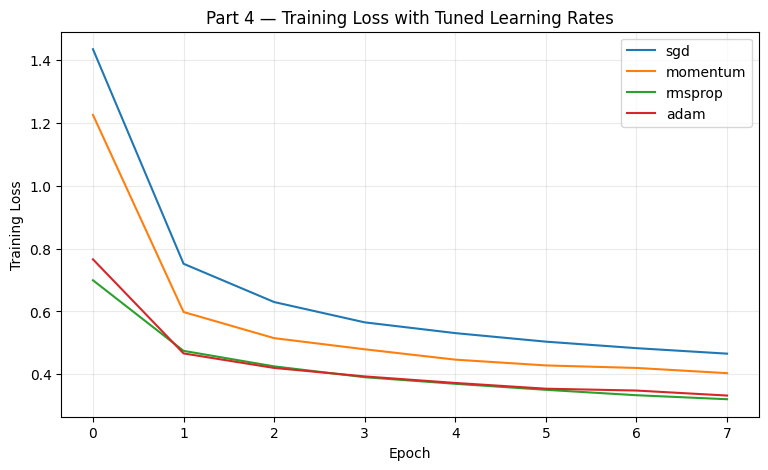

In [10]:
# Part 4: Optimizers — Faster Version

ARCH = (128, 64)
COMMON_LR = 1e-3
OPTIMIZERS = ["sgd", "momentum", "rmsprop", "adam"]

def run_optimizer(opt_name, lr, epochs=8):
    seed_everything(SEED)

    model = MLPClassifier(
        widths=ARCH,
        activation="relu"
    )

    start = time.perf_counter()

    model, hist = train_model(
        model,
        X_train, y_train,
        X_val, y_val,
        epochs=epochs,
        lr=lr,
        optimizer_name=opt_name,
        verbose=False
    )

    elapsed = time.perf_counter() - start

    reached = np.where(np.array(hist["val_acc"]) >= 0.85)[0]
    epoch85 = int(reached[0] + 1) if len(reached) else np.nan

    return {
        "optimizer": opt_name,
        "learning_rate": lr,
        "epochs_to_85": epoch85,
        "wall_clock_seconds": elapsed,
        "final_val_accuracy": hist["val_acc"][-1],
        "history": hist
    }

print("Running same learning-rate experiments...")

same_lr_results = {}

for opt in OPTIMIZERS:
    print(f"Running {opt}...")
    same_lr_results[opt] = run_optimizer(
        opt,
        COMMON_LR,
        epochs=8
    )

tuned_lrs = {
    "sgd": 0.05,
    "momentum": 0.01,
    "rmsprop": 0.001,
    "adam": 0.001
}

print("\nRunning tuned learning-rate experiments...")

tuned_results = {}

for opt in OPTIMIZERS:
    print(f"Running {opt}...")
    tuned_results[opt] = run_optimizer(
        opt,
        tuned_lrs[opt],
        epochs=8
    )

same_lr_table = pd.DataFrame([
    {k: v for k, v in r.items() if k != "history"}
    for r in same_lr_results.values()
])

tuned_table = pd.DataFrame([
    {k: v for k, v in r.items() if k != "history"}
    for r in tuned_results.values()
])


print("\nSame learning rate:")
display(same_lr_table)

print("\nTuned learning rates:")
display(tuned_table)

plt.figure(figsize=(9, 5))

for opt, result in tuned_results.items():
    plt.plot(
        result["history"]["train_loss"],
        label=opt
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Part 4 — Training Loss with Tuned Learning Rates")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## Part 5: Forcing Overfitting

Reduced training set: 2,000 samples
Validation set:       12,000 samples
Epoch 01/100 | train loss 1.9960 acc 0.3315 | val loss 1.2718 acc 0.5434
Epoch 02/100 | train loss 1.1518 acc 0.5495 | val loss 0.9771 acc 0.5845
Epoch 03/100 | train loss 0.9316 acc 0.6305 | val loss 0.8756 acc 0.6648
Epoch 04/100 | train loss 0.8042 acc 0.6925 | val loss 0.7545 acc 0.7104
Epoch 05/100 | train loss 0.7317 acc 0.7195 | val loss 0.6943 acc 0.7268
Epoch 06/100 | train loss 0.6893 acc 0.7380 | val loss 0.6829 acc 0.7388
Epoch 07/100 | train loss 0.6579 acc 0.7595 | val loss 0.6617 acc 0.7502
Epoch 08/100 | train loss 0.5720 acc 0.7865 | val loss 0.6093 acc 0.7789
Epoch 09/100 | train loss 0.5286 acc 0.8155 | val loss 0.6526 acc 0.7674
Epoch 10/100 | train loss 0.5427 acc 0.7895 | val loss 0.5742 acc 0.7887
Epoch 11/100 | train loss 0.4896 acc 0.8255 | val loss 0.5699 acc 0.7883
Epoch 12/100 | train loss 0.4381 acc 0.8400 | val loss 0.6022 acc 0.7877
Epoch 13/100 | train loss 0.4188 acc 0.8485 | val l

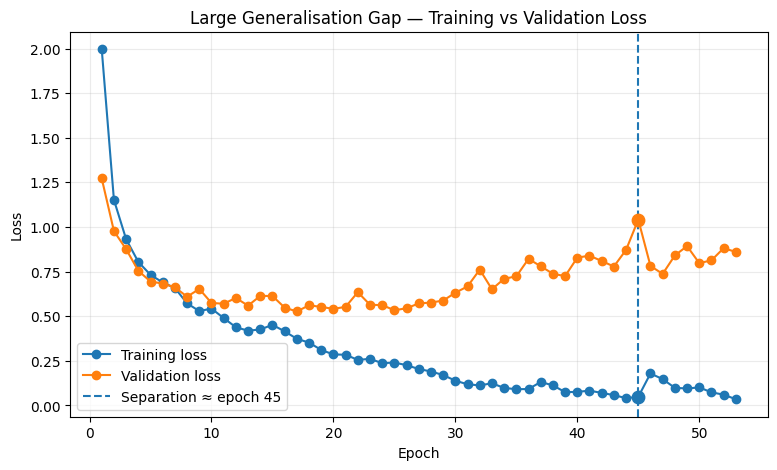


GENERALISATION GAP RESULTS
Training samples:              2,000
Network architecture:          784 → 512 → 512 → 512 → 512 → 10
Epochs completed:              53
Separation epoch:              45

Final training loss:            0.0348
Final validation loss:          0.8601

Final training accuracy:        99.1000%
Final validation accuracy:      82.0500%

Generalisation gap:             17.0500%
Generalisation gap (percentage points):                      17.05 pp

Diagnosis: HIGH VARIANCE

Justification:
The model fits the small training set extremely well (99.10%) but performs substantially worse on unseen validation data (82.05%). The resulting generalisation gap is 17.05%, indicating overfitting and therefore high variance.


In [11]:
# Part 5: Forcing overfitting

seed_everything(SEED)

X_train_gap, _, y_train_gap, _ = train_test_split(
    X_train,
    y_train,
    train_size=2000,
    random_state=SEED,
    stratify=y_train
)

print(f"Reduced training set: {len(X_train_gap):,} samples")
print(f"Validation set:       {len(X_val):,} samples")

gap_model = MLPClassifier(
    widths=(512, 512, 512, 512),
    activation="relu"
).to(DEVICE)

optimizer = torch.optim.Adam(
    gap_model.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()
train_loader_gap = make_loader(
    X_train_gap,
    y_train_gap,
    batch_size=BATCH_SIZE,
    shuffle=True
)

MAX_EPOCHS = 100
history_gap = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(MAX_EPOCHS):

    gap_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader_gap:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        logits = gap_model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(xb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(xb)

    train_loss = running_loss / total
    train_acc = correct / total

    val_loss, val_acc = evaluate_model(
        gap_model,
        X_val,
        y_val
    )

    history_gap["train_loss"].append(train_loss)
    history_gap["val_loss"].append(val_loss)
    history_gap["train_acc"].append(train_acc)
    history_gap["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    if train_acc > 0.99:
        print(
            f"\nTraining accuracy exceeded 99% at epoch "
            f"{epoch+1}."
        )
        break

train_losses = np.array(history_gap["train_loss"])
val_losses = np.array(history_gap["val_loss"])

loss_difference = np.abs(val_losses - train_losses)

initial_difference = loss_difference[0]
threshold = max(initial_difference * 3, 0.20)

separation_candidates = np.where(
    loss_difference >= threshold
)[0]

if len(separation_candidates) > 0:
    separation_epoch = int(separation_candidates[0] + 1)
else:
    separation_epoch = int(np.argmax(loss_difference) + 1)

final_train_acc = history_gap["train_acc"][-1]
final_val_acc = history_gap["val_acc"][-1]

generalisation_gap = final_train_acc - final_val_acc

epochs = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation loss"
)

plt.axvline(
    separation_epoch,
    linestyle="--",
    label=f"Separation ≈ epoch {separation_epoch}"
)

plt.scatter(
    separation_epoch,
    train_losses[separation_epoch - 1],
    s=80,
    zorder=5
)

plt.scatter(
    separation_epoch,
    val_losses[separation_epoch - 1],
    s=80,
    zorder=5
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Large Generalisation Gap — Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("\n" + "=" * 60)
print("GENERALISATION GAP RESULTS")
print("=" * 60)

print(f"Training samples:              {len(X_train_gap):,}")
print(f"Network architecture:          784 → 512 → 512 → 512 → 512 → 10")
print(f"Epochs completed:              {len(epochs)}")
print(f"Separation epoch:              {separation_epoch}")

print(f"\nFinal training loss:            {train_losses[-1]:.4f}")
print(f"Final validation loss:          {val_losses[-1]:.4f}")

print(f"\nFinal training accuracy:        {final_train_acc:.4%}")
print(f"Final validation accuracy:      {final_val_acc:.4%}")

print(f"\nGeneralisation gap:             {generalisation_gap:.4%}")
print(
    f"Generalisation gap (percentage "
    f"points):                      "
    f"{generalisation_gap * 100:.2f} pp"
)

if final_train_acc > 0.99 and generalisation_gap >= 0.10:
    diagnosis = "HIGH VARIANCE"
elif final_train_acc < 0.80 and final_val_acc < 0.80:
    diagnosis = "HIGH BIAS"
elif final_train_acc < 0.80 and generalisation_gap >= 0.10:
    diagnosis = "BOTH HIGH BIAS AND HIGH VARIANCE"
else:
    diagnosis = "NO STRONG EVIDENCE OF HIGH BIAS"

print(f"\nDiagnosis: {diagnosis}")

print("\nJustification:")
if diagnosis == "HIGH VARIANCE":
    print(
        f"The model fits the small training set extremely well "
        f"({final_train_acc:.2%}) but performs substantially worse "
        f"on unseen validation data ({final_val_acc:.2%}). "
        f"The resulting generalisation gap is "
        f"{generalisation_gap:.2%}, indicating overfitting and "
        f"therefore high variance."
    )
elif diagnosis == "HIGH BIAS":
    print(
        f"Both training accuracy ({final_train_acc:.2%}) and "
        f"validation accuracy ({final_val_acc:.2%}) are low, "
        f"indicating that the model is underfitting."
    )
else:
    print(
        f"The training accuracy is {final_train_acc:.2%} while "
        f"validation accuracy is {final_val_acc:.2%}, giving a "
        f"generalisation gap of {generalisation_gap:.2%}."
    )

## Part 6: Regularisation Study

[1/12] START  Baseline (no regularisation)
[1/12] DONE   Baseline (no regularisation)           | train=88.55%  val=81.59%  gap= 6.96pp  stopped@20  (52.4s)

[2/12] START  L2 weight decay (0.0001)
[2/12] DONE   L2 weight decay (0.0001)               | train=85.85%  val=79.62%  gap= 6.23pp  stopped@16  (43.8s)

[3/12] START  L2 weight decay (0.001)
[3/12] DONE   L2 weight decay (0.001)                | train=86.65%  val=81.15%  gap= 5.50pp  stopped@18  (46.6s)

[4/12] START  L2 weight decay (0.01)
[4/12] DONE   L2 weight decay (0.01)                 | train=75.90%  val=72.49%  gap= 3.41pp  stopped@20  (52.8s)

[5/12] START  L1 penalty (1e-05)
[5/12] DONE   L1 penalty (1e-05)                     | train=82.05%  val=80.36%  gap= 1.69pp  stopped@15  (41.4s)

[6/12] START  Dropout (0.2)
[6/12] DONE   Dropout (0.2)                          | train=87.75%  val=81.33%  gap= 6.42pp  stopped@19  (69.4s)

[7/12] START  Dropout (0.5)
[7/12] DONE   Dropout (0.5)                          | train=81.

,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),no regularisation,88.55%,81.59%,6.96%
1,L2 weight decay (0.01),0.01,75.90%,72.49%,3.41%
2,L1 penalty (1e-05),1e-05,82.05%,80.36%,1.69%
3,Dropout (0.7),0.7,63.70%,69.20%,-5.50%
4,Batch normalisation,—,96.80%,81.05%,15.75%
5,Early stopping (patience=3),patience=3,88.55%,81.59%,6.96%
6,Data augmentation,—,81.25%,80.04%,1.21%
7,"More training data (10,000)","10,000",87.61%,83.97%,3.63%
8,"More training data (20,000)","20,000",91.81%,86.82%,4.99%



L1 weights below 1e-3: 28.02%
Early stopping: patience=3, stopped at epoch 20


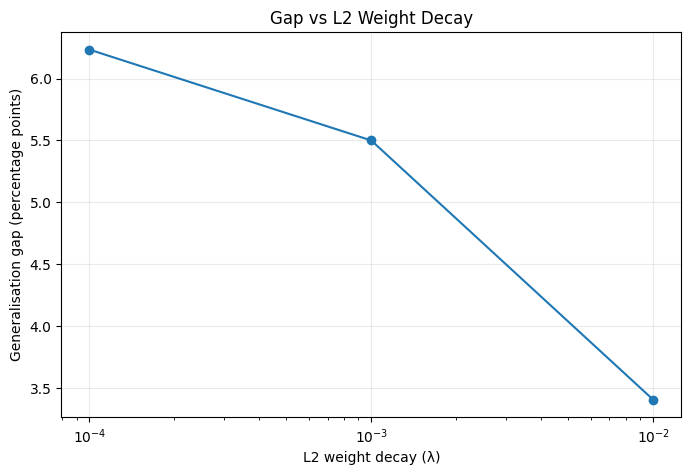

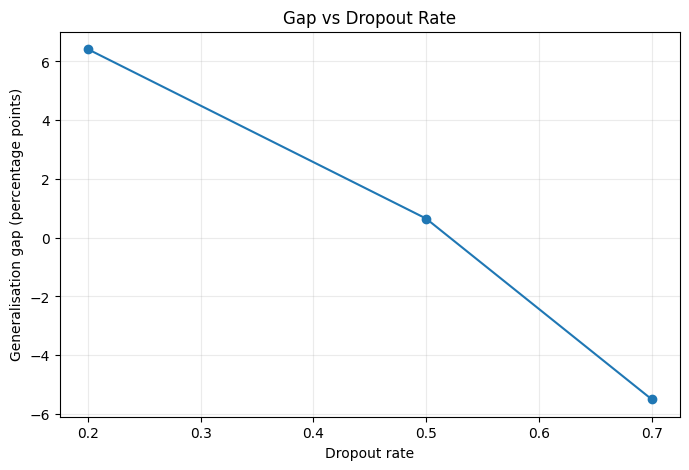

In [15]:
## Part 6: Regularisation Study


WIDTHS_REG = (512, 512, 512, 512)
EPOCHS_REG = 20
LR_REG     = 1e-3
PATIENCE   = 3

X_reg, _, y_reg, _ = train_test_split(
    X_train, y_train, train_size=2000, random_state=SEED, stratify=y_train
)

_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
])

class AugDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float().view(-1, 1, 28, 28)
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return _aug(self.X[i]).view(-1), self.y[i]

def run_reg_experiment(idx, total, name, Xtr, ytr,
                       weight_decay=0.0, l1=0.0, dropout=0.0,
                       batchnorm=False, augmentation=False,
                       patience=PATIENCE):
    print(f"[{idx}/{total}] START  {name}", flush=True)
    t0 = time.time()
    seed_everything(SEED)

    model = MLPClassifier(widths=WIDTHS_REG, activation="relu",
                          dropout=dropout, batchnorm=batchnorm).to(DEVICE)

    if augmentation:
        loader = DataLoader(
            AugDataset(Xtr, ytr),
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=0,
            pin_memory=False,
        )
    else:
        ds = TensorDataset(
            torch.from_numpy(Xtr).float(),
            torch.from_numpy(ytr).long(),
        )
        loader = DataLoader(
            ds,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

    opt  = torch.optim.Adam(model.parameters(), lr=LR_REG, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()

    best_state, best_val, wait, stopped = None, float("inf"), 0, EPOCHS_REG
    tr_acc = va_acc = 0.0

    for epoch in range(EPOCHS_REG):
        model.train()
        rloss = correct = total_n = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = crit(logits, yb)
            if l1 > 0:
                loss = loss + l1 * sum(p.abs().sum() for p in model.parameters())
            loss.backward()
            opt.step()
            rloss    += loss.item() * len(xb)
            correct  += (logits.argmax(1) == yb).sum().item()
            total_n  += len(xb)

        tr_acc = correct / total_n
        va_loss, va_acc = evaluate_model(model, X_val, y_val)

        if va_loss < best_val - 1e-4:
            best_val   = va_loss
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if patience is not None and wait >= patience:
                stopped = epoch + 1
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        _, va_acc = evaluate_model(model, X_val, y_val)

    gap = tr_acc - va_acc
    dt  = time.time() - t0
    print(f"[{idx}/{total}] DONE   {name:38s} | "
          f"train={tr_acc:6.2%}  val={va_acc:6.2%}  gap={gap*100:5.2f}pp  "
          f"stopped@{stopped:2d}  ({dt:4.1f}s)\n", flush=True)

    return {"Method": name, "Train accuracy": tr_acc,
            "Validation accuracy": va_acc, "Gap": gap,
            "Model": model, "Stopped epoch": stopped}

results = []

results.append(run_reg_experiment(1, 12, "Baseline (no regularisation)",
                                  X_reg, y_reg, patience=PATIENCE))

l2_values = [1e-4, 1e-3, 1e-2]
l2_results = []
for i, lam in enumerate(l2_values, start=2):
    l2_results.append(run_reg_experiment(
        i, 12, f"L2 weight decay ({lam:g})", X_reg, y_reg, weight_decay=lam))
results.append(min(l2_results, key=lambda x: x["Gap"]))

l1_value = 1e-5
l1_result = run_reg_experiment(5, 12, f"L1 penalty ({l1_value:g})",
                               X_reg, y_reg, l1=l1_value)
results.append(l1_result)
weights = torch.cat([p.detach().abs().flatten().cpu()
                     for p in l1_result["Model"].parameters() if p.ndim == 2])
l1_small_weights = 100 * (weights < 1e-3).float().mean().item()

dropout_values = [0.2, 0.5, 0.7]
dropout_results = []
for i, rate in enumerate(dropout_values, start=6):
    dropout_results.append(run_reg_experiment(
        i, 12, f"Dropout ({rate})", X_reg, y_reg, dropout=rate))
results.append(min(dropout_results, key=lambda x: x["Gap"]))

results.append(run_reg_experiment(9, 12, "Batch normalisation",
                                  X_reg, y_reg, batchnorm=True))

early_result = run_reg_experiment(10, 12, f"Early stopping (patience={PATIENCE})",
                                  X_reg, y_reg)
results.append(early_result)

results.append(run_reg_experiment(11, 12, "Data augmentation",
                                  X_reg, y_reg, augmentation=True))

for n in [10000, 20000]:
    X_n, _, y_n, _ = train_test_split(X_train, y_train, train_size=n,
                                      random_state=SEED, stratify=y_train)
    results.append(run_reg_experiment(12, 12, f"More training data ({n:,})", X_n, y_n))

print("=" * 78)
print("FINAL RESULTS TABLE")
print("=" * 78)
results_table = pd.DataFrame([{
    "Method": r["Method"],
    "Setting": r["Method"].split("(",1)[1][:-1] if "(" in r["Method"] else "—",
    "Train accuracy": f'{r["Train accuracy"]:.2%}',
    "Validation accuracy": f'{r["Validation accuracy"]:.2%}',
    "Gap": f'{r["Gap"]:.2%}',
} for r in results])
display(results_table)

print(f"\nL1 weights below 1e-3: {l1_small_weights:.2f}%")
print(f"Early stopping: patience={PATIENCE}, stopped at epoch {early_result['Stopped epoch']}")

plt.figure(figsize=(8,5))
plt.plot(l2_values, [r["Gap"]*100 for r in l2_results], marker="o")
plt.xscale("log")
plt.xlabel("L2 weight decay (λ)")
plt.ylabel("Generalisation gap (percentage points)")
plt.title("Gap vs L2 Weight Decay")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(dropout_values, [r["Gap"]*100 for r in dropout_results], marker="o")
plt.xlabel("Dropout rate")
plt.ylabel("Generalisation gap (percentage points)")
plt.title("Gap vs Dropout Rate")
plt.grid(True, alpha=0.25)
plt.show()

## Part 7: Hyperparameter Tuning with k-Fold Cross-Validation

Random search over hyperparameters
Search space:
  lr: [0.0003, 0.001, 0.003]
  width: [(128, 64), (256, 128), (256, 256), (512, 256)]
  dropout: [0.0, 0.2, 0.4, 0.5]
  weight_decay: [0.0, 0.0001, 0.001]

Configs to try: 12  |  CV folds: 5  |  Search epochs: 8

[ 1/12] lr=0.003   width=(128, 64)      dropout=0.4  wd=0.0001  ... CV mean=0.8649  std=0.0026  (folds: ['0.868', '0.865', '0.863', '0.861', '0.868'])  [123.4s]
[ 2/12] lr=0.003   width=(256, 128)     dropout=0.0  wd=0.001   ... CV mean=0.8682  std=0.0035  (folds: ['0.873', '0.868', '0.863', '0.866', '0.871'])  [146.1s]
[ 3/12] lr=0.0003  width=(128, 64)      dropout=0.4  wd=0.001   ... CV mean=0.8425  std=0.0044  (folds: ['0.850', '0.844', '0.840', '0.837', '0.841'])  [215.6s]
[ 4/12] lr=0.003   width=(256, 256)     dropout=0.4  wd=0.001   ... CV mean=0.8549  std=0.0047  (folds: ['0.864', '0.854', '0.850', '0.854', '0.853'])  [185.2s]
[ 5/12] lr=0.0003  width=(256, 256)     dropout=0.5  wd=0.0001  ... CV mean=0.8610  std=0.0025

,lr,width,dropout,weight_decay,CV mean,CV std
0,0.0010,"(256, 256)",0.2,0.0000,0.8786,0.0025
1,0.0030,"(512, 256)",0.2,0.0001,0.8781,0.0038
2,0.0010,"(256, 256)",0.0,0.0010,0.8696,0.0026
3,0.0010,"(512, 256)",0.2,0.0010,0.8692,0.0051
4,0.0030,"(256, 128)",0.0,0.0010,0.8682,0.0035
5,0.0030,"(128, 64)",0.4,0.0001,0.8649,0.0026
6,0.0030,"(256, 256)",0.5,0.0000,0.8638,0.0049
7,0.0030,"(128, 64)",0.2,0.0010,0.8612,0.0026
8,0.0003,"(256, 256)",0.5,0.0001,0.8610,0.0025
9,0.0010,"(128, 64)",0.5,0.0000,0.8604,0.0052



Top 5 configurations:


,Rank,lr,width,dropout,weight_decay,CV mean,CV std
0,1,0.001,"(256, 256)",0.2,0.0000,0.8786,0.0025
1,2,0.003,"(512, 256)",0.2,0.0001,0.8781,0.0038
2,3,0.001,"(256, 256)",0.0,0.0010,0.8696,0.0026
3,4,0.001,"(512, 256)",0.2,0.0010,0.8692,0.0051
4,5,0.003,"(256, 128)",0.0,0.0010,0.8682,0.0035



Selected configuration:
  lr           = 0.001
  width        = (256, 256)
  dropout      = 0.2
  weight_decay = 0.0
  -> CV mean   = 0.8786  (std 0.0025)

Retraining selected config on full training set (48,000 samples) for up to 25 epochs ...
  epoch  1/25 | train acc 0.7495 | val loss 0.4519 | val acc 0.8333
  epoch  2/25 | train acc 0.8395 | val loss 0.4039 | val acc 0.8496
  epoch  3/25 | train acc 0.8588 | val loss 0.3740 | val acc 0.8602
  epoch  4/25 | train acc 0.8678 | val loss 0.3585 | val acc 0.8682
  epoch  5/25 | train acc 0.8747 | val loss 0.3350 | val acc 0.8754
  epoch  6/25 | train acc 0.8793 | val loss 0.3362 | val acc 0.8793
  epoch  7/25 | train acc 0.8841 | val loss 0.3248 | val acc 0.8790
  epoch  8/25 | train acc 0.8875 | val loss 0.3171 | val acc 0.8803
  epoch  9/25 | train acc 0.8915 | val loss 0.3160 | val acc 0.8853
  epoch 10/25 | train acc 0.8932 | val loss 0.3225 | val acc 0.8762
  epoch 11/25 | train acc 0.8949 | val loss 0.3124 | val acc 0.8845
  epoc

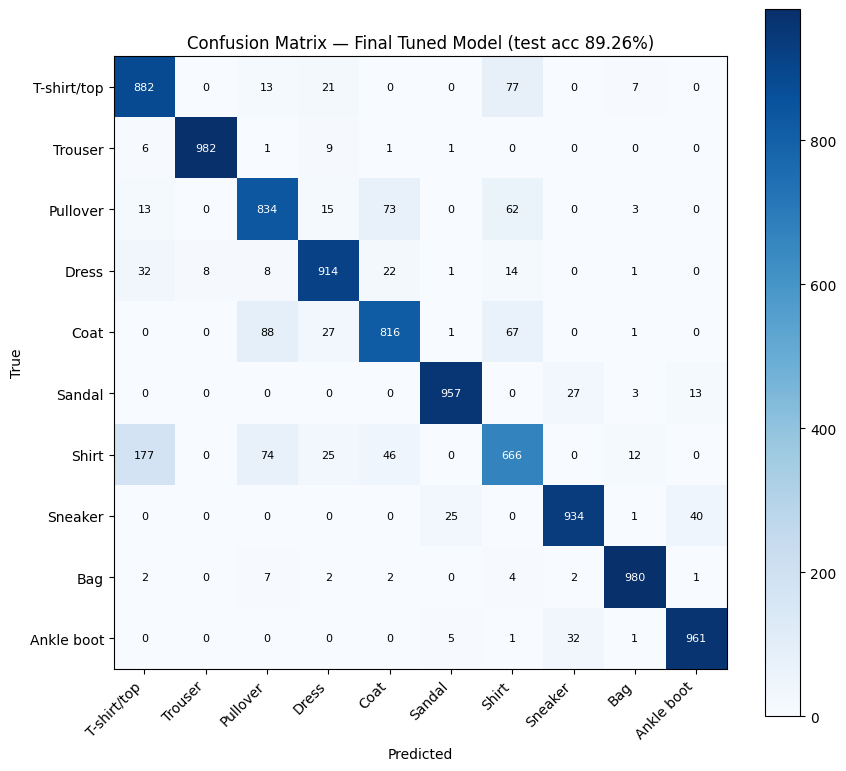

In [18]:
# Part 7: Hyperparameter Tuning with k-Fold Cross-Validation


SEARCH_EPOCHS  = 8
FINAL_EPOCHS   = 25
N_CONFIGS      = 12
N_FOLDS        = 5
SEARCH_LR      = 1e-3
SEARCH_BATCH   = 256
FINAL_BATCH    = 256
PATIENCE_SEARCH = 2
PATIENCE_FINAL  = 4

search_space = {
    "lr":            [3e-4, 1e-3, 3e-3],
    "width":         [(128, 64), (256, 128), (256, 256), (512, 256)],
    "dropout":       [0.0, 0.2, 0.4, 0.5],
    "weight_decay":  [0.0, 1e-4, 1e-3],
}

def sample_config(rng):
    width_idx = int(rng.integers(len(search_space["width"])))
    return {
        "lr":           float(rng.choice(search_space["lr"])),
        "width":        tuple(search_space["width"][width_idx]),
        "dropout":      float(rng.choice(search_space["dropout"])),
        "weight_decay": float(rng.choice(search_space["weight_decay"])),
    }

def train_one_fold(cfg, Xtr, ytr, Xva, yva, seed, max_epochs, patience):
    seed_everything(seed)
    model = MLPClassifier(
        widths=cfg["width"], activation="relu",
        dropout=cfg["dropout"], batchnorm=False,
    ).to(DEVICE)

    ds = TensorDataset(torch.from_numpy(Xtr).float(),
                       torch.from_numpy(ytr).long())
    loader = DataLoader(ds, batch_size=SEARCH_BATCH, shuffle=True,
                        num_workers=0, pin_memory=torch.cuda.is_available())

    opt  = torch.optim.Adam(model.parameters(),
                            lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    crit = nn.CrossEntropyLoss()

    best_val, best_state, wait = float("inf"), None, 0
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()

        vl, _ = evaluate_model(model, Xva, yva)
        if vl < best_val - 1e-4:
            best_val   = vl
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    _, va_acc = evaluate_model(model, Xva, yva)
    return va_acc

def cross_validate(cfg, X, y, n_folds=N_FOLDS, seed=SEED):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    scores = []
    for fold_i, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
        acc = train_one_fold(
            cfg, X[tr_idx], y[tr_idx], X[va_idx], y[va_idx],
            seed=seed + fold_i, max_epochs=SEARCH_EPOCHS, patience=PATIENCE_SEARCH
        )
        scores.append(acc)
    return np.array(scores)

print("Random search over hyperparameters")
print("Search space:")
for k, v in search_space.items():
    print(f"  {k}: {v}")
print(f"\nConfigs to try: {N_CONFIGS}  |  CV folds: {N_FOLDS}  |  "
      f"Search epochs: {SEARCH_EPOCHS}\n")

rng = np.random.default_rng(SEED)
configs = []
seen = set()
while len(configs) < N_CONFIGS:
    c = sample_config(rng)
    key = (c["lr"], c["width"], c["dropout"], c["weight_decay"])
    if key not in seen:
        seen.add(key)
        configs.append(c)

search_results = []
t_search_start = time.time()

for i, cfg in enumerate(configs, 1):
    print(f"[{i:2d}/{N_CONFIGS}] lr={cfg['lr']:<7g} width={str(cfg['width']):<14s} "
          f"dropout={cfg['dropout']:<4} wd={cfg['weight_decay']:<7g} ... ",
          end="", flush=True)
    t0 = time.time()
    scores = cross_validate(cfg, X_train, y_train)
    mean_s, std_s = float(scores.mean()), float(scores.std())
    print(f"CV mean={mean_s:.4f}  std={std_s:.4f}  "
          f"(folds: {[f'{s:.3f}' for s in scores]})  [{time.time()-t0:.1f}s]",
          flush=True)
    search_results.append({
        "config": cfg, "mean": mean_s, "std": std_s,
        "folds": scores.tolist(),
    })

print(f"\nSearch finished in {time.time()-t_search_start:.1f}s")

search_df = pd.DataFrame([{
    "lr": r["config"]["lr"],
    "width": str(r["config"]["width"]),
    "dropout": r["config"]["dropout"],
    "weight_decay": r["config"]["weight_decay"],
    "CV mean": f'{r["mean"]:.4f}',
    "CV std": f'{r["std"]:.4f}',
} for r in search_results]).sort_values("CV mean", ascending=False)

print("\nAll configurations ranked by CV mean:")
display(search_df.reset_index(drop=True))

top5 = sorted(search_results, key=lambda r: r["mean"], reverse=True)[:5]
print("\nTop 5 configurations:")
top5_df = pd.DataFrame([{
    "Rank": i + 1,
    "lr": r["config"]["lr"],
    "width": str(r["config"]["width"]),
    "dropout": r["config"]["dropout"],
    "weight_decay": r["config"]["weight_decay"],
    "CV mean": f'{r["mean"]:.4f}',
    "CV std": f'{r["std"]:.4f}',
} for i, r in enumerate(top5)])
display(top5_df)

best_cfg = top5[0]["config"]
print(f"\nSelected configuration:")
print(f"  lr           = {best_cfg['lr']}")
print(f"  width        = {best_cfg['width']}")
print(f"  dropout      = {best_cfg['dropout']}")
print(f"  weight_decay = {best_cfg['weight_decay']}")
print(f"  -> CV mean   = {top5[0]['mean']:.4f}  (std {top5[0]['std']:.4f})")

print(f"\nRetraining selected config on full training set "
      f"({len(X_train):,} samples) for up to {FINAL_EPOCHS} epochs ...")

seed_everything(SEED)
final_model = MLPClassifier(
    widths=best_cfg["width"], activation="relu",
    dropout=best_cfg["dropout"], batchnorm=False,
).to(DEVICE)

final_ds = TensorDataset(torch.from_numpy(X_train).float(),
                         torch.from_numpy(y_train).long())
final_loader = DataLoader(final_ds, batch_size=FINAL_BATCH, shuffle=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())

final_opt  = torch.optim.Adam(final_model.parameters(),
                              lr=best_cfg["lr"],
                              weight_decay=best_cfg["weight_decay"])
final_crit = nn.CrossEntropyLoss()

best_val, best_state, wait = float("inf"), None, 0
t_final_start = time.time()

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    rloss = correct = total_n = 0
    for xb, yb in final_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        final_opt.zero_grad(set_to_none=True)
        logits = final_model(xb)
        loss = final_crit(logits, yb)
        loss.backward()
        final_opt.step()
        rloss   += loss.item() * len(xb)
        correct += (logits.argmax(1) == yb).sum().item()
        total_n += len(xb)

    tr_acc = correct / total_n
    vl, va_acc = evaluate_model(final_model, X_val, y_val)

    print(f"  epoch {epoch+1:2d}/{FINAL_EPOCHS} | "
          f"train acc {tr_acc:.4f} | val loss {vl:.4f} | val acc {va_acc:.4f}",
          flush=True)

    if vl < best_val - 1e-4:
        best_val   = vl
        best_state = {k: v.detach().cpu().clone()
                      for k, v in final_model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE_FINAL:
            print(f"  early stop at epoch {epoch+1}")
            break

if best_state is not None:
    final_model.load_state_dict(best_state)

print(f"Final training finished in {time.time()-t_final_start:.1f}s")

final_model.eval()
X_test_t = torch.from_numpy(X_test).float()
y_test_t = torch.from_numpy(y_test).long()

with torch.no_grad():
    test_loader = DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size=512, shuffle=False, num_workers=0,
    )
    preds = []
    for xb, _ in test_loader:
        xb = xb.to(DEVICE)
        preds.append(final_model(xb).argmax(1).cpu().numpy())
    y_pred = np.concatenate(preds)

y_true = y_test

acc      = accuracy_score(y_true, y_pred)
prec_mac = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_mac  = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_mac   = f1_score(y_true, y_pred, average="macro", zero_division=0)
cm       = confusion_matrix(y_true, y_pred)

print("\n" + "=" * 70)
print("FINAL TEST-SET EVALUATION (one shot)")
print("=" * 70)
print(f"Accuracy         : {acc:.4f}  ({acc:.2%})")
print(f"Macro precision  : {prec_mac:.4f}")
print(f"Macro recall     : {rec_mac:.4f}")
print(f"Macro F1         : {f1_mac:.4f}")

baseline_test_acc = 0.8829

improvement_pp = (acc - baseline_test_acc) * 100
print(f"\nPart 2 baseline (validation acc) : {baseline_test_acc:.4f}  "
      f"({baseline_test_acc:.2%})")
print(f"Tuned final model (test acc)     : {acc:.4f}  ({acc:.2%})")
print(f"Improvement                      : {improvement_pp:+.2f} percentage points")

if improvement_pp > 0:
    print("The tuned model improved over the Part 2 baseline.")
else:
    print("The tuned model did NOT improve over the Part 2 baseline.")
    print("Likely reasons: the baseline was already well-tuned, "
          "the search space did not contain a better region, "
          "or 8 search epochs were not enough for good configs to separate.")

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — Final Tuned Model (test acc {acc:.2%})")
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()